<a href="https://colab.research.google.com/github/niyasnasmal8-jpg/ict_assignments/blob/main/Assignment_Data_Preprocessing01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Import Libraries & Load Dataset**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Upload file in Colab first, then use:
data = pd.read_csv('/content/employee.csv')

print(data.head())
print(data.info())
print(data.describe())

            name   age   income gender  department grade  performance_score
0    Allen Smith  45.0      NaN    NaN  Operations    G3                723
1        S Kumar   NaN  16000.0      F     Finance    G0                520
2    Jack Morgan  32.0  35000.0      M     Finance    G2                674
3      Ying Chin  45.0  65000.0      F       Sales    G3                556
4  Dheeraj Patel  30.0  42000.0      F  Operations    G2                711
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               9 non-null      object 
 1   age                7 non-null      float64
 2   income             7 non-null      float64
 3   gender             7 non-null      object 
 4   department         9 non-null      object 
 5   grade              9 non-null      object 
 6   performance_score  9 non-null      int64  
dtypes: floa

**2. Set "name" as Index**

In [ ]:
data.set_index("name", inplace=True)
print(data.head())

                age   income gender  department grade  performance_score
name                                                                    
Allen Smith    45.0      NaN    NaN  Operations    G3                723
S Kumar         NaN  16000.0      F     Finance    G0                520
Jack Morgan    32.0  35000.0      M     Finance    G2                674
Ying Chin      45.0  65000.0      F       Sales    G3                556
Dheeraj Patel  30.0  42000.0      F  Operations    G2                711


**3. Employees with Performance Score > 700**

In [ ]:
high_perf = data[data["performance_score"] > 700]
print(high_perf)

                age   income gender  department grade  performance_score
name                                                                    
Allen Smith    45.0      NaN    NaN  Operations    G3                723
Dheeraj Patel  30.0  42000.0      F  Operations    G2                711
Josh Wills     54.0  52000.0      F     Finance    G3                901
Leo Duck       23.0  98000.0      M       Sales    G4                709


**4. Employees with Performance Score Between 500 and 700**

In [ ]:
mid_perf = data[(data["performance_score"] > 500) &
                (data["performance_score"] < 700)]
print(mid_perf)

                age   income gender department grade  performance_score
name                                                                   
S Kumar         NaN  16000.0      F    Finance    G0                520
Jack Morgan    32.0  35000.0      M    Finance    G2                674
Ying Chin      45.0  65000.0      F      Sales    G3                556
Satyam Sharma   NaN  62000.0    NaN      Sales    G3                649


**5. Handle Missing Values**

In [ ]:
print(data.isnull().sum())

# Fill numeric columns with mean
data.fillna(data.mean(numeric_only=True), inplace=True)

# Fill categorical columns with mode
for col in data.select_dtypes(include='object').columns:
    data[col].fillna(data[col].mode()[0], inplace=True)

print("Missing values handled")

age                  2
income               2
gender               2
department           0
grade                0
performance_score    0
dtype: int64
Missing values handled


/tmp/ipykernel_13334/688021004.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


**6. Handle Outliers Using Percentiles**

Outliers removed


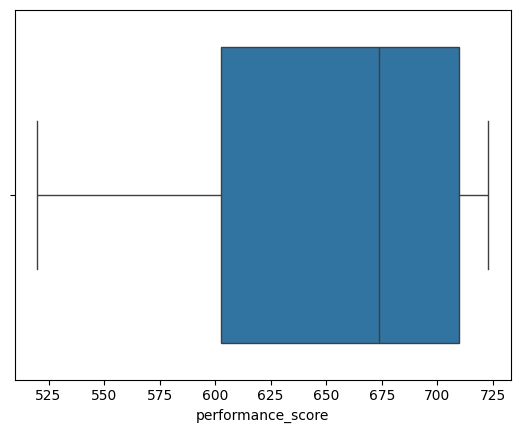

In [ ]:
lower = data["performance_score"].quantile(0.01)
upper = data["performance_score"].quantile(0.99)

data = data[(data["performance_score"] >= lower) &
            (data["performance_score"] <= upper)]

print("Outliers removed")

# Optional visualization
sns.boxplot(x=data["performance_score"])
plt.show()

**7. One-Hot Encoding (Gender)**

In [ ]:
data = pd.get_dummies(data, columns=["gender"])
print(data.head())

                     age        income  department grade  performance_score  \
name                                                                          
Allen Smith    45.000000  52857.142857  Operations    G3                723   
S Kumar        40.428571  16000.000000     Finance    G0                520   
Jack Morgan    32.000000  35000.000000     Finance    G2                674   
Ying Chin      45.000000  65000.000000       Sales    G3                556   
Dheeraj Patel  30.000000  42000.000000  Operations    G2                711   

               gender_F  gender_M  
name                               
Allen Smith        True     False  
S Kumar            True     False  
Jack Morgan       False      True  
Ying Chin          True     False  
Dheeraj Patel      True     False  
